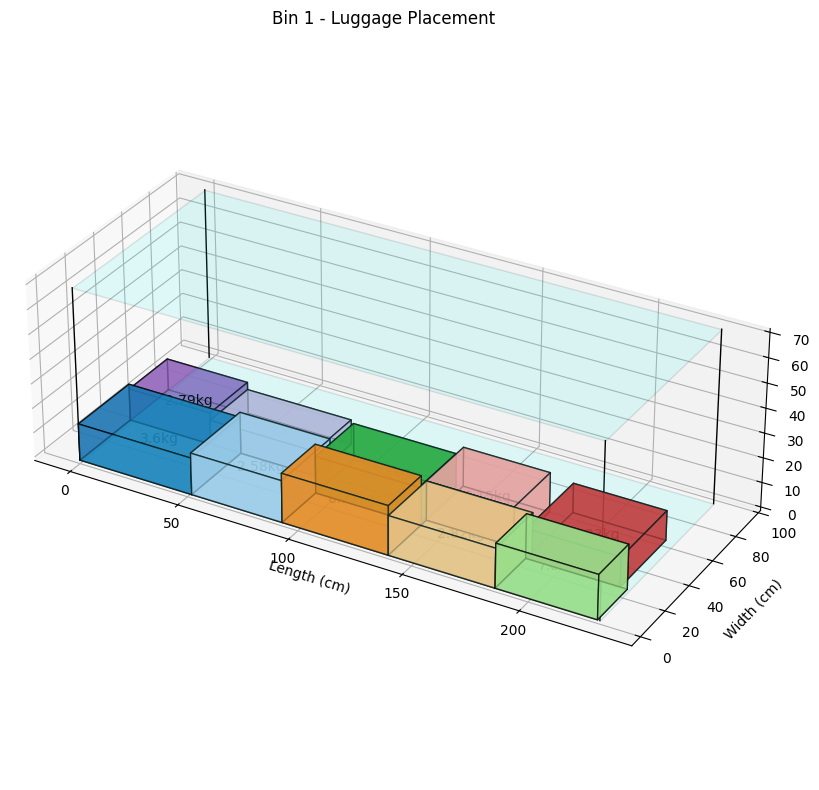

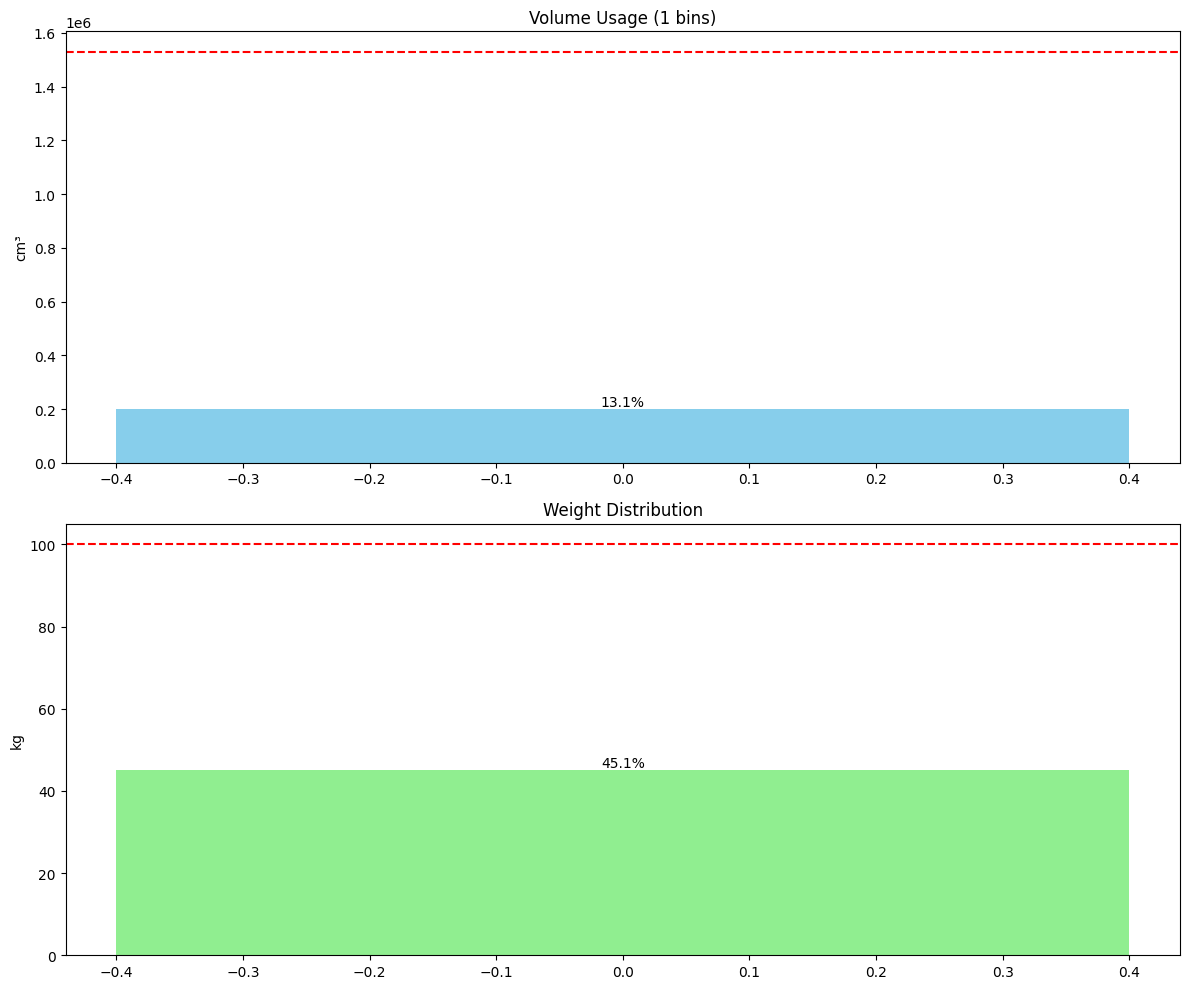


SUMMARY:
Bins used: 1
Avg volume usage: 13.1%
Avg weight usage: 45.1%

Bin 1 contents:
  52x36x15cm, 3.6kg at (0,0,0)
  41x36x17cm, 2.58kg at (52,0,0)
  47x25x20cm, 6.27kg at (93,0,0)
  46x29x16cm, 2.82kg at (140,0,0)
  46x29x15cm, 2.88kg at (93,25,0)
  43x24x18cm, 7.88kg at (186,0,0)
  40x38x12cm, 7.23kg at (186,24,0)
  38x29x16cm, 5.15kg at (140,29,0)
  38x28x13cm, 2.79kg at (0,36,0)
  48x28x10cm, 3.94kg at (38,36,0)


In [58]:
import random
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Luggage generator
LUGGAGE_SIZE_RANGE = [(38, 24, 10), (55, 40, 23)]  # (L, W, H) in cm
LUGGAGE_WEIGHT_RANGE = (2, 4, 6, 8)  

def generate_luggage(num_items):
    luggage_data = []
    for _ in range(num_items):
        length = random.randint(LUGGAGE_SIZE_RANGE[0][0], LUGGAGE_SIZE_RANGE[1][0])
        width = random.randint(LUGGAGE_SIZE_RANGE[0][1], LUGGAGE_SIZE_RANGE[1][1])
        height = random.randint(LUGGAGE_SIZE_RANGE[0][2], LUGGAGE_SIZE_RANGE[1][2])
        weight = round(random.uniform(LUGGAGE_WEIGHT_RANGE[0], LUGGAGE_WEIGHT_RANGE[-1]), 2)
        luggage_data.append((length, width, height, weight))
    return luggage_data

# First fit bin packing AKA the core algorithm 
def first_fit_decreasing(luggage_data, bin_capacity):
    # Bin dimensions (230x95x70cm)
    bin_length, bin_width, bin_height = 230, 95, 70
    max_weight = bin_capacity[1]
    
    # Sort by volume descending
    luggage_data = sorted(luggage_data, key=lambda x: x[0]*x[1]*x[2], reverse=True)
    bins = []
    
    for item in luggage_data:
        l, w, h, weight = item
        placed = False
        
        # Try all 6 possible rotations
        rotations = [
            (l, w, h), (l, h, w),
            (w, l, h), (w, h, l),
            (h, l, w), (h, w, l)
        ]
        
        for bin in bins:
            if bin['weight_used'] + weight > max_weight:
                continue
                
            # Try each rotation
            for rot in rotations:
                pos = find_available_position(bin['items'], rot, bin_length, bin_width, bin_height)
                if pos:
                    bin['items'].append((*rot, weight, *pos))
                    bin['weight_used'] += weight
                    bin['volume_used'] += rot[0]*rot[1]*rot[2]
                    placed = True
                    break
            if placed:
                break
                
        if not placed:
            # Try all rotations for new bin
            for rot in rotations:
                if (rot[0] <= bin_length and 
                    rot[1] <= bin_width and 
                    rot[2] <= bin_height):
                    bins.append({
                        'items': [(*rot, weight, 0, 0, 0)],
                        'weight_used': weight,
                        'volume_used': rot[0]*rot[1]*rot[2]
                    })
                    placed = True
                    break
    return bins

def find_available_position(items, item_dim, bin_length, bin_width, bin_height):
    if not items:
        return (0, 0, 0)
        
    # Generate candidate positions near existing items
    candidates = set()
    for existing in items:
        x, y, z = existing[4], existing[5], existing[6]
        el, ew, eh = existing[0], existing[1], existing[2]
        
        # Try positions adjacent to existing items
        candidates.add((x + el, y, z))          # Right
        candidates.add((x, y + ew, z))          # Behind
        candidates.add((x, y, z + eh))          # Above
        candidates.add((x + el, y + ew, z))     # Right and behind
        candidates.add((x + el, y, z + eh))     # Right and above
        candidates.add((x, y + ew, z + eh))     # Behind and above
    
    # Check each candidate position
    for pos in sorted(candidates, key=lambda p: (p[2], p[1], p[0])):  # Prefer lower z, then y, then x
        x, y, z = pos
        new_l, new_w, new_h = item_dim
        
        # Check if within bin dimensions
        if (x + new_l > bin_length or 
            y + new_w > bin_width or 
            z + new_h > bin_height):
            continue
            
        # Check for collisions with existing items
        collision = False
        for existing in items:
            ex_x, ex_y, ex_z = existing[4], existing[5], existing[6]
            ex_l, ex_w, ex_h = existing[0], existing[1], existing[2]
            
            if (x < ex_x + ex_l and x + new_l > ex_x and
                y < ex_y + ex_w and y + new_w > ex_y and
                z < ex_z + ex_h and z + new_h > ex_z):
                collision = True
                break
                
        if not collision:
            return pos
            
    return None

def visualize_3d_bin(bin_items, bin_capacity, bin_num):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Bin dimensions
    bin_length, bin_width, bin_height = 230, 95, 70
    
    # Draw bin container
    bin_corners = [
        [0, 0, 0],
        [bin_length, 0, 0],
        [bin_length, bin_width, 0],
        [0, bin_width, 0],
        [0, 0, bin_height],
        [bin_length, 0, bin_height],
        [bin_length, bin_width, bin_height],
        [0, bin_width, bin_height]
    ]
    
    # Draw bin wireframe
    edges = [
        [bin_corners[0], bin_corners[1], bin_corners[2], bin_corners[3]],
        [bin_corners[4], bin_corners[5], bin_corners[6], bin_corners[7]],
        [bin_corners[0], bin_corners[4]],
        [bin_corners[1], bin_corners[5]],
        [bin_corners[2], bin_corners[6]],
        [bin_corners[3], bin_corners[7]]
    ]
    
    for edge in edges:
        if len(edge) == 4:
            face = Poly3DCollection([edge], alpha=0.1, linewidths=1, edgecolor='k')
            face.set_facecolor('cyan')
            ax.add_collection3d(face)
        else:
            xs, ys, zs = zip(*edge)
            ax.plot(xs, ys, zs, color='k', linewidth=1)
    
    # Draw luggage items
    colors = plt.cm.tab20.colors
    for i, item in enumerate(bin_items):
        x, y, z = item[4], item[5], item[6]
        l, w, h = item[0], item[1], item[2]
        
        # Define the 8 corners of the luggage item
        corners = [
            [x, y, z],
            [x+l, y, z],
            [x+l, y+w, z],
            [x, y+w, z],
            [x, y, z+h],
            [x+l, y, z+h],
            [x+l, y+w, z+h],
            [x, y+w, z+h]
        ]
        
        # Define the 6 faces of the luggage item
        faces = [
            [corners[0], corners[1], corners[2], corners[3]],  # bottom
            [corners[4], corners[5], corners[6], corners[7]],  # top
            [corners[0], corners[1], corners[5], corners[4]],  # front
            [corners[2], corners[3], corners[7], corners[6]],  # back
            [corners[1], corners[2], corners[6], corners[5]],  # right
            [corners[0], corners[3], corners[7], corners[4]]   # left
        ]
        
        # Draw the luggage item
        item_face = Poly3DCollection(faces, alpha=0.7, linewidths=1, edgecolor='k')
        item_face.set_facecolor(colors[i % len(colors)])
        ax.add_collection3d(item_face)
        
        # Add label with weight
        ax.text(x+l/2, y+w/2, z+h/2, f'{item[3]}kg', 
               color='black', ha='center', va='center')
    
    ax.set_title(f'Bin {bin_num} - Luggage Placement')
    ax.set_xlabel('Length (cm)')
    ax.set_ylabel('Width (cm)')
    ax.set_zlabel('Height (cm)')
    
    # Set equal aspect ratio
    ax.set_box_aspect([bin_length, bin_width, bin_height])
    plt.tight_layout()
    plt.show()

def visualize_luggage_packing(bins, bin_capacity):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Calculate metrics
    bin_volumes = [bin['volume_used'] for bin in bins]
    bin_weights = [bin['weight_used'] for bin in bins]
    volume_percent = [v/bin_capacity[0]*100 for v in bin_volumes]
    weight_percent = [w/bin_capacity[1]*100 for w in bin_weights]
    
    # Volume plot
    bars1 = ax1.bar(range(len(bins)), bin_volumes, color='skyblue')
    ax1.axhline(bin_capacity[0], color='r', linestyle='--')
    ax1.set_title(f'Volume Usage ({len(bins)} bins)')
    ax1.set_ylabel('cm³')
    
    # Weight plot
    bars2 = ax2.bar(range(len(bins)), bin_weights, color='lightgreen')
    ax2.axhline(bin_capacity[1], color='r', linestyle='--')
    ax2.set_title('Weight Distribution')
    ax2.set_ylabel('kg')
    
    # Add labels
    for ax, percent in zip([ax1, ax2], [volume_percent, weight_percent]):
        for i, p in enumerate(percent):
            ax.text(i, bin_volumes[i] if ax == ax1 else bin_weights[i], 
                   f'{p:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics 
    print(f"\nSUMMARY:")
    print(f"Bins used: {len(bins)}")
    print(f"Avg volume usage: {np.mean(volume_percent):.1f}%")
    print(f"Avg weight usage: {np.mean(weight_percent):.1f}%")

# Run the complete pipeline
luggage_items = generate_luggage(10)  # Generates a specific amount of luggage 
bin_capacity = (230*95*70, 100)  # This sets the volume (cm³) and weight (kg)
bins = first_fit_decreasing(luggage_items, bin_capacity)

# Visualize the first few bins in 3D
for i, bin in enumerate(bins[:3]):  # Shows first 3 bins change no. to change how many shown
    visualize_3d_bin(bin['items'], bin_capacity, i+1)

# 2D visualization
visualize_luggage_packing(bins, bin_capacity)

# Print bin contents
for i, bin in enumerate(bins[:6]):  
    print(f"\nBin {i+1} contents:")
    for item in bin['items']:
        print(f"  {item[0]}x{item[1]}x{item[2]}cm, {item[3]}kg at ({item[4]},{item[5]},{item[6]})")